# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

Importações das bibliotecas

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml


# Carregamento do dataset e dimensionamento

In [4]:
print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(np.uint8)
print("Download concluído!")

Baixando o dataset MNIST...
Download concluído!


In [5]:
print(f"Formato de X (amostras, pixels por imagem): {X.shape}")
print(f"Formato de y (rótulos): {y.shape}")
print(f"Tipo de dado dos pixels: {X.dtype}")
print(f"Valor mínimo de pixel: {X.min()} | Valor máximo de pixel: {X.max()}")

Formato de X (amostras, pixels por imagem): (70000, 784)
Formato de y (rótulos): (70000,)
Tipo de dado dos pixels: int64
Valor mínimo de pixel: 0 | Valor máximo de pixel: 255


# Distribuição das classes (Balanceamento)

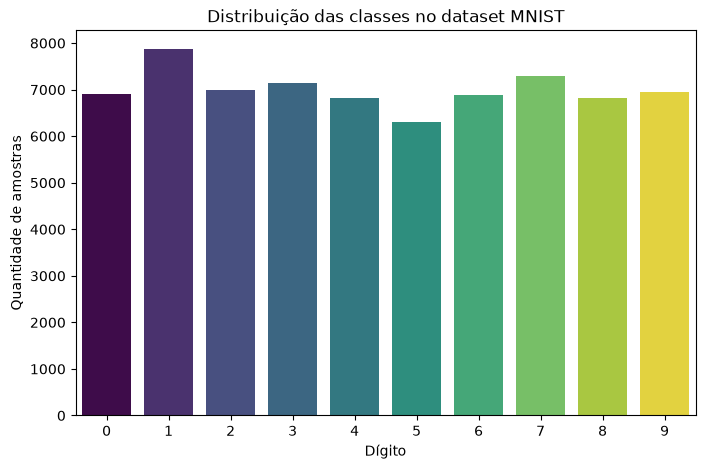

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
dtype: int64


In [6]:
classes, contagens = np.unique(y, return_counts=True)

plt.figure(figsize=(8, 5))
sns.barplot(x=classes, y=contagens, hue=classes, palette='viridis', legend=False)
plt.title("Distribuição das classes no dataset MNIST")
plt.xlabel("Dígito")
plt.ylabel("Quantidade de amostras")
plt.show()

print(pd.Series(contagens, index=classes))

# Grade visual 2×5 (com um exemplo de CADA dígito)

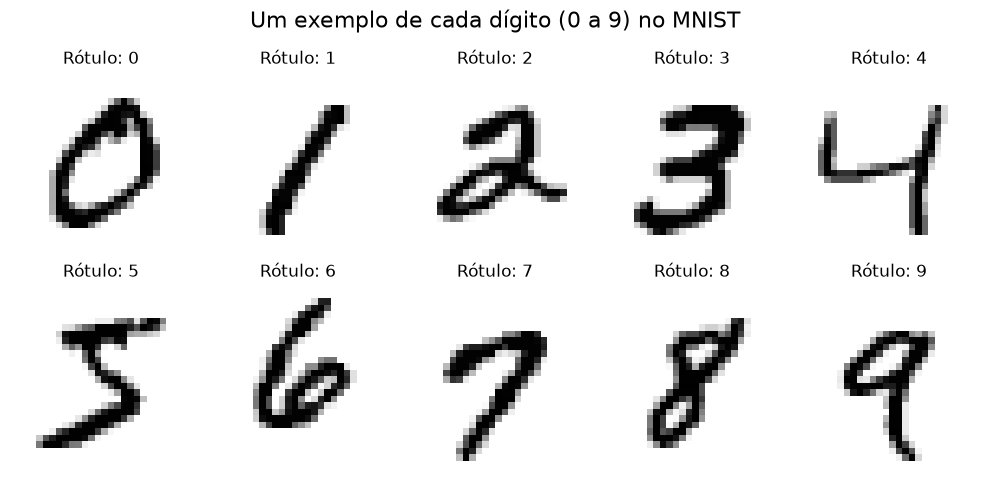

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for digito, ax in enumerate(axes.flat):
    # Pega o índice da PRIMEIRA imagem que representa esse dígito
    indice = np.where(y == digito)[0][0]
    ax.imshow(X[indice].reshape(28, 28), cmap='binary')
    ax.set_title(f"Rótulo: {y[indice]}")
    ax.axis('off')

plt.suptitle("Um exemplo de cada dígito (0 a 9) no MNIST", fontsize=16)
plt.tight_layout()
plt.show()

# Interpretação da estrutura dos dados

Imagine o dataset MNIST (70.000 imagens de dígitos manuscritos de 0 a 9 em 
escala de cinza, 28x28 pixels) como uma pilha de cartas de baralho desenhadas 
à mão por milhares de pessoas diferentes. Cada carta do MNIST é um pequeno 
tabuleiro quadriculado de 28 linhas por 28 colunas (totalizando 784 
quadradinhos).

Cada quadradinho dessa carta não é só preto ou branco, mas guarda um número 
que indica a intensidade do tom: 0 é preto, um número intermediário como 130 
é cinza, e 255 é branco.

Quando olhamos para a carta na mão, vemos o desenho em duas dimensões (altura 
e largura). O problema é que algoritmos tabulares clássicos (como KNN, 
Regressão Logística ou Random Forest) não sabem "segurar" uma carta quadrada. 
Eles só sabem ler uma planilha do Excel com linhas e colunas normais.

Para isso, precisamos "cortar" a carta em 28 tiras horizontais (cada tira tem 
1 quadradinho de altura por 28 de largura) e colocar uma tira ao lado da 
outra sequencialmente até a 28ª tira. O resultado não é mais uma carta 
quadrada: virou uma fita longa e esticada com 784 quadradinhos em fila 
indiana, virando assim uma planilha.

Agora qualquer algoritmo tradicional de Machine Learning consegue treinar 
com essa tabela, tratando cada pixel simplesmente como uma característica 
numérica comum (como idade, salário ou temperatura).

# Fase 2: Pré-processamento e Divisão dos Dados

Normalização dos pixels

In [8]:
# Os pixels originais variam de 0 a 255 (inteiros).
# Vamos "reescalar" esses valores para o intervalo [0.0, 1.0], dividindo tudo por 255.0.
# Isso deixa a escala numérica pequena e uniforme, o que ajuda o treinamento
# da Rede Neural a ser mais rápido e estável (evita gradientes instáveis).
X_normalizado = X / 255.0

print(f"Antes  -> mínimo: {X.min()}, máximo: {X.max()}")
print(f"Depois -> mínimo: {X_normalizado.min()}, máximo: {X_normalizado.max()}")

Antes  -> mínimo: 0, máximo: 255
Depois -> mínimo: 0.0, máximo: 1.0


In [9]:
from sklearn.model_selection import train_test_split

# O train_test_split só sabe dividir em DUAS partes por vez.
# Como queremos TRÊS conjuntos (treino, validação, teste), fazemos em 2 etapas.

# Etapa 1: separamos primeiro o conjunto de TESTE (vai ficar "trancado na gaveta"
# até a Fase 4 - avaliação final). Usamos 15% dos dados para teste.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_normalizado, y,
    test_size=0.15,
    random_state=42,   # garante que o "sorteio" seja sempre o mesmo, reprodutível
    stratify=y          # mantém a proporção de cada dígito (0-9) igual à original
)

# Etapa 2: do que sobrou (X_temp, 85% dos dados), separamos a VALIDAÇÃO.
# Queremos que a validação também represente ~15% do TOTAL original,
# não 15% do que sobrou. Por isso calculamos a fração corrigida:
proporcao_validacao = 0.15 / 0.85  # ≈ 0.1765

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=proporcao_validacao,
    random_state=42,
    stratify=y_temp
)

In [10]:
total = len(X_normalizado)

print(f"Treino:    {X_train.shape[0]:>6} amostras  ({X_train.shape[0]/total*100:.1f}%)")
print(f"Validação: {X_val.shape[0]:>6} amostras  ({X_val.shape[0]/total*100:.1f}%)")
print(f"Teste:     {X_test.shape[0]:>6} amostras  ({X_test.shape[0]/total*100:.1f}%)")

Treino:     49000 amostras  (70.0%)
Validação:  10500 amostras  (15.0%)
Teste:      10500 amostras  (15.0%)


In [11]:
import pandas as pd

for nome, y_conjunto in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    distrib = pd.Series(y_conjunto).value_counts(normalize=True).sort_index() * 100
    print(f"\nDistribuição de dígitos em {nome} (%):")
    print(distrib.round(2))


Distribuição de dígitos em Treino (%):
0     9.86
1    11.25
2     9.99
3    10.20
4     9.75
5     9.02
6     9.82
7    10.42
8     9.75
9     9.94
Name: proportion, dtype: float64

Distribuição de dígitos em Validação (%):
0     9.87
1    11.25
2     9.99
3    10.20
4     9.74
5     9.02
6     9.82
7    10.42
8     9.75
9     9.94
Name: proportion, dtype: float64

Distribuição de dígitos em Teste (%):
0     9.86
1    11.26
2     9.98
3    10.20
4     9.75
5     9.02
6     9.82
7    10.42
8     9.75
9     9.94
Name: proportion, dtype: float64


# Por que dividir em Treino, Validação e Teste?

Imagine um cantor/compositor que pretende lançar uma música.

Ele começa compondo, rabiscando em papel a letra da música e colocando os primeiros acordes. Nesse estágio, (Treino) ele tem a liberdade para errar e recomeçar.

Após o treino, ele parte para os ensaios em estúdio (Validação), onde tem segurança para poder ajustar o que ainda é necessário, mesmo já estando com a versão quase pronta.

Quando os ajustes necessários foram feitos e validados, a música foi gravada e está pronta para a rádio (Teste), onde o público tem acesso e a atenção e o retorno necessário da gravadora (aceitação do público e crítica). Nesse momento não existe mais a opção de ajustar a música. Ou ela é boa ou não. 

Conectando com o Machine Learning — Se a música fosse lançada antes, apenas para uma parte do público em específico (como para um fã clube do artista). Se a música não fosse boa, a "espiada" desse grupo, faria com que a música fosse alterada antes de ser tocada nas rádios (Teste). A mesma coisa aconteceria se o cientista de dados "espiasse" o resultado do teste antes da hora e ajustasse o modelo em cima disso. Isso é o que conhecemos por data leakage. Dessa forma o teste não seria confiável pois o modelo aprendeu tudo antes da hora.

# Fase 3: Treinamento e Ajuste de Hiperparâmetros

In [12]:
import time

# Este dicionário vai guardar os resultados de TODOS os modelos (KNN, Random Forest, Rede Neural).
# Vamos reaproveitar ele na Fase 4 para montar a tabela comparativa final.
resultados_modelos = {}

## Modelo 1: K-Nearest Neighbors (KNN)


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Vamos testar combinações de 2 hiperparâmetros:
# - n_neighbors: quantos "vizinhos" o modelo consulta antes de decidir
# - weights: se todos os vizinhos "votam" igual (uniform) ou se os mais
#            próximos têm voto com mais peso (distance)

valores_k = [3, 5, 7]
valores_weights = ['uniform', 'distance']

resultados_busca_knn = []

for k in valores_k:
    for peso in valores_weights:
        inicio = time.time()

        knn = KNeighborsClassifier(n_neighbors=k, weights=peso, n_jobs=-1)
        knn.fit(X_train, y_train)

        y_val_pred = knn.predict(X_val)
        acuracia_val = accuracy_score(y_val, y_val_pred)

        tempo_total = time.time() - inicio

        resultados_busca_knn.append({
            'n_neighbors': k,
            'weights': peso,
            'acuracia_validacao': acuracia_val,
            'tempo_segundos': tempo_total
        })

        print(f"k={k}, weights='{peso}' -> acurácia val: {acuracia_val:.4f} | tempo: {tempo_total:.1f}s")

k=3, weights='uniform' -> acurácia val: 0.9711 | tempo: 41.1s
k=3, weights='distance' -> acurácia val: 0.9717 | tempo: 40.5s
k=5, weights='uniform' -> acurácia val: 0.9703 | tempo: 43.8s
k=5, weights='distance' -> acurácia val: 0.9719 | tempo: 42.3s
k=7, weights='uniform' -> acurácia val: 0.9695 | tempo: 49.3s
k=7, weights='distance' -> acurácia val: 0.9709 | tempo: 70.1s


In [14]:
import pandas as pd

df_resultados_knn = pd.DataFrame(resultados_busca_knn)
df_resultados_knn.sort_values('acuracia_validacao', ascending=False)

# Pegando a linha com a maior acurácia de validação
melhor_config = df_resultados_knn.loc[df_resultados_knn['acuracia_validacao'].idxmax()]
melhor_k = int(melhor_config['n_neighbors'])
melhor_peso = melhor_config['weights']

print(f"Melhor configuração encontrada: n_neighbors={melhor_k}, weights='{melhor_peso}'")

# Treinando o modelo final com essa configuração (ainda usando só X_train)
inicio = time.time()
knn_final = KNeighborsClassifier(n_neighbors=melhor_k, weights=melhor_peso, n_jobs=-1)
knn_final.fit(X_train, y_train)
tempo_treino_knn = time.time() - inicio

print(f"Modelo final treinado em {tempo_treino_knn:.2f} segundos.")

Melhor configuração encontrada: n_neighbors=5, weights='distance'
Modelo final treinado em 0.07 segundos.


In [15]:
resultados_modelos['KNN'] = {
    'melhores_hiperparametros': {'n_neighbors': melhor_k, 'weights': melhor_peso},
    'acuracia_validacao': melhor_config['acuracia_validacao'],
    'tempo_treino_segundos': tempo_treino_knn
}

resultados_modelos



{'KNN': {'melhores_hiperparametros': {'n_neighbors': 5, 'weights': 'distance'},
  'acuracia_validacao': np.float64(0.9719047619047619),
  'tempo_treino_segundos': 0.07016491889953613}}

# Interpretando o resultado do KNN

## Por que o valor de K importa?

Voltando à analogia do baralho de cartas, se escolhermos um K muito pequeno (por exemplo, K=1), o modelo decide olhando para apenas uma única carta do baralho de treino: aquela com o padrão de pixels mais idêntico ao da imagem nova, sem nenhuma margem para confirmação ou desempate. Isso não é confiável se esse único vizinho for um caso raro, borrado ou ruidoso.

Isso é arriscado porque se esse único vizinho for um dígito escrito com letra muito feia, um traço torto acidental ou um ruído de escaneamento (por exemplo, um "7" mal desenhado que acabou ficando idêntico a um "1"), o modelo confiará cegamente nele e classificará o dígito de forma errada. Em termos técnicos, o modelo sofre de overfitting (sobreajuste) e alta variância, ficando hipersensível a qualquer imperfeição dos dados de treino.

Por outro lado, se escolhermos um K muito grande (por exemplo, K=50), o modelo passa a "ouvir" uma multidão de 50 cartas diferentes, incluindo exemplos que estão muito distantes no espaço de pixels e que já pertencem a classes completamente diferentes daquela região.

Isso também é um problema porque ao diluir a decisão com opiniões de exemplos que não são realmente parecidos com a imagem analisada, a fronteira entre os números fica borrada. O modelo perde a capacidade de captar nuances locais (como o traço cortado de um "7" ou a abertura sutil de um "8") e passa a favorecer simplesmente a classe que tiver mais cartas naquela área geral. Tecnicamente, isso gera underfitting (subajuste) e alto viés.

No nosso caso, a busca de hiperparâmetros encontrou K=5 como o melhor equilíbrio, porque ele é ímpar (evitando empates na votação), grande o suficiente para ignorar uma carta atípica ou ruidosa pelo voto da maioria, e pequeno o bastante para considerar apenas as cartas de caligrafia verdadeiramente próximas e relevantes.